#                                  timeseris Multi Label Clasification - GRU

# Load Data

In [1]:
import pandas as pd
import os
import numpy as np

In [2]:

file_name = "microsoft_stock_data"
root_folder = f'timeseris/multi-label-clasification/rnn/{file_name}/' 
os.makedirs(root_folder, exist_ok=True)

df = pd.read_csv('sample_data/'+file_name+'.csv')

df.head()

,Date,Close,High,Low,Open,Volume
0,3/26/1986,0.057906,0.058437,0.055781,0.056312,22752000
1,3/27/1986,0.058969,0.058969,0.057906,0.057906,16848000
2,3/31/1986,0.058437,0.058969,0.057375,0.058969,12873600
3,4/1/1986,0.057906,0.058437,0.057906,0.058437,11088000
4,4/2/1986,0.058437,0.059500,0.057906,0.057906,27014400


#### Pilih tahun mulai data

In [3]:
# Pastikan kolom Date dalam format datetime
df['Date'] = pd.to_datetime(df['Date'])

# Filter data mulai dari tahun 2000
df = df[df['Date'] >= '1995-01-01']

# (Opsional) urutkan berdasarkan tanggal
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,1995-01-03,2.302169,2.352372,2.299778,2.352372,39545600
1,1995-01-04,2.318903,2.323684,2.275872,2.304559,51611200
2,1995-01-05,2.280653,2.333246,2.271091,2.328465,39824000
3,1995-01-06,2.318903,2.342809,2.285434,2.290216,46681600
4,1995-01-09,2.304561,2.333248,2.285436,2.328467,46000000


#### tambahkan status green, red, dan netral || DayName

In [4]:
# === Tambahkan kolom nama hari ===
df['Day'] =  df['Date'].dt.day_name()  # bahasa Inggris

# Buat kondisi
conditions = [
    df['Close'] > df['Open'],
    df['Close'] < df['Open'],
    df['Close'] == df['Open']
]
choices = ['green', 'red', 'red']

df['Status'] = np.select(conditions, choices)
df.head()

,Date,Close,High,Low,Open,Volume,Day,Status
0,1995-01-03,2.302169,2.352372,2.299778,2.352372,39545600,Tuesday,red
1,1995-01-04,2.318903,2.323684,2.275872,2.304559,51611200,Wednesday,green
2,1995-01-05,2.280653,2.333246,2.271091,2.328465,39824000,Thursday,red
3,1995-01-06,2.318903,2.342809,2.285434,2.290216,46681600,Friday,green
4,1995-01-09,2.304561,2.333248,2.285436,2.328467,46000000,Monday,red


#### Chart Donat

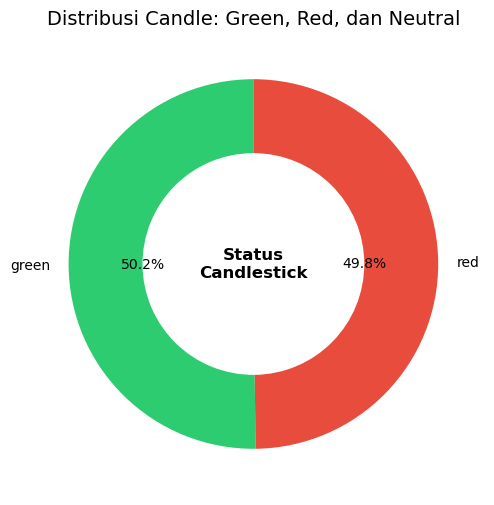

In [5]:
import matplotlib.pyplot as plt

# Contoh: df sudah punya kolom Status
# (kalau belum, bisa pakai kode sebelumnya untuk menambahkannya)

# Hitung jumlah masing-masing status
status_counts = df['Status'].value_counts()

# Warna donat
colors = {
    'green': '#2ecc71',   # hijau
    'red': '#e74c3c',     # merah
    'neutral': '#95a5a6'  # abu-abu
}

# Buat donut chart
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[colors[k] for k in status_counts.index],
    wedgeprops=dict(width=0.4)  # buat efek donut
)

# Tambahkan teks di tengah
ax.text(0, 0, 'Status\nCandlestick', ha='center', va='center', fontsize=12, weight='bold')

plt.title('Distribusi Candle: Green, Red, dan Neutral', fontsize=14)
plt.show()

In [6]:
status_counts

Status
green    3890
red      3861
Name: count, dtype: int64

#### LabelEncoder

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
#labeling
df['label_Day']            = le.fit_transform(df['Day'])
df.head()

,Date,Close,High,Low,Open,Volume,Day,Status,label_Day
0,1995-01-03,2.302169,2.352372,2.299778,2.352372,39545600,Tuesday,red,3
1,1995-01-04,2.318903,2.323684,2.275872,2.304559,51611200,Wednesday,green,4
2,1995-01-05,2.280653,2.333246,2.271091,2.328465,39824000,Thursday,red,2
3,1995-01-06,2.318903,2.342809,2.285434,2.290216,46681600,Friday,green,0
4,1995-01-09,2.304561,2.333248,2.285436,2.328467,46000000,Monday,red,1


#### Scaler

In [8]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Contoh: buat dan fit scaler
scaler = MinMaxScaler()
cols = [
    'label_Day',
    'Close', 
    'High', 
    'Low',
    'Open',
    'Volume', 
]

# Dictionary untuk menyimpan hasil transformasi
scaled_data = {}

# Loop untuk setiap kolom
for col in cols:
    scaler = MinMaxScaler()
    df[[col]] = scaler.fit_transform(df[[col]])  # scaling per kolom
    joblib.dump(scaler, os.path.join(root_folder, f'scaler_{col}.pkl'))
    scaled_data[col] = scaler
    print(f"✅ Scaler for '{col}' saved as scaler_{col}.pkl")

print("\nAll individual scalers saved successfully!")

✅ Scaler for 'label_Day' saved as scaler_label_Day.pkl
✅ Scaler for 'Close' saved as scaler_Close.pkl
✅ Scaler for 'High' saved as scaler_High.pkl
✅ Scaler for 'Low' saved as scaler_Low.pkl
✅ Scaler for 'Open' saved as scaler_Open.pkl
✅ Scaler for 'Volume' saved as scaler_Volume.pkl

All individual scalers saved successfully!


In [9]:
df.head()

,Date,Close,High,Low,Open,Volume,Day,Status,label_Day
0,1995-01-03,0.000085,0.000147,0.000136,0.000191,0.055458,Tuesday,red,0.75
1,1995-01-04,0.000117,0.000095,0.000090,0.000104,0.076122,Wednesday,green,1.00
2,1995-01-05,0.000045,0.000113,0.000081,0.000147,0.055935,Thursday,red,0.50
3,1995-01-06,0.000117,0.000130,0.000108,0.000078,0.067679,Friday,green,0.00
4,1995-01-09,0.000090,0.000113,0.000108,0.000147,0.066512,Monday,red,0.25


#### Mapping label

In [10]:
import json
mapping_dicts = {}

cols = [
    'Day',
]

for col in cols:
    label_col = f"label_{col}"
    mapping_dicts[col] = dict(zip(df[col], df[label_col]))


with open(root_folder + 'label_mappings.json', 'w') as f:
    json.dump(mapping_dicts, f, indent=2)

rows = []
for col, mapping in mapping_dicts.items():
    for k, v in mapping.items():
        rows.append({'feature': col, 'original_value': k, 'label_value': v})

mapping_table = pd.DataFrame(rows)
print(mapping_table)

  feature original_value  label_value
0     Day        Tuesday         0.75
1     Day      Wednesday         1.00
2     Day       Thursday         0.50
3     Day         Friday         0.00
4     Day         Monday         0.25


#### Select Kolom To Trian

In [11]:
col_target = 'Status'
cols = [
    'Date',
    'label_Day', 
    'Close', 
    'High',
    'Low',
    'Open',
    'Volume',
    col_target
]
df = df[cols].copy()
df.head()

,Date,label_Day,Close,High,Low,Open,Volume,Status
0,1995-01-03,0.75,0.000085,0.000147,0.000136,0.000191,0.055458,red
1,1995-01-04,1.00,0.000117,0.000095,0.000090,0.000104,0.076122,green
2,1995-01-05,0.50,0.000045,0.000113,0.000081,0.000147,0.055935,red
3,1995-01-06,0.00,0.000117,0.000130,0.000108,0.000078,0.067679,green
4,1995-01-09,0.25,0.000090,0.000113,0.000108,0.000147,0.066512,red


#### Tentukan target -> one-hot encoding

In [12]:
y_counts = df[col_target].value_counts(normalize=True)
labels = list(y_counts.index)

df_y_encoded = pd.get_dummies(df[col_target], prefix='y')

# Pastikan semua nama kolom lowercase dan spasi → underscore
df_y_encoded.columns = (
    df_y_encoded.columns.str.lower()
                        .str.replace(' ', '_')
)

# Gabungkan ke DataFrame utama
df = pd.concat([df.drop(col_target, axis=1), df_y_encoded.astype(int)], axis=1)
df.head()

,Date,label_Day,Close,High,Low,Open,Volume,y_green,y_red
0,1995-01-03,0.75,0.000085,0.000147,0.000136,0.000191,0.055458,0,1
1,1995-01-04,1.00,0.000117,0.000095,0.000090,0.000104,0.076122,1,0
2,1995-01-05,0.50,0.000045,0.000113,0.000081,0.000147,0.055935,0,1
3,1995-01-06,0.00,0.000117,0.000130,0.000108,0.000078,0.067679,1,0
4,1995-01-09,0.25,0.000090,0.000113,0.000108,0.000147,0.066512,0,1


# Data Load To Train

#### select Future to traian

In [13]:
feature_cols = [
    'label_Day', 
    'Close', 
    'High',
    'Low',
    'Open',
    'Volume',
]
target_cols = [col for col in df.columns if col.startswith('y_')]

#### Split data

In [14]:
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

tgl_pembatas = '2020-01-01'
X_train = df[df['Date'] <= tgl_pembatas]
X_test  = df[df['Date'] > tgl_pembatas]
print(f'Train : f{X_train.shape}')
print(f'Test  : f{X_test.shape}')

Train : f(6294, 9)
Test  : f(1457, 9)


#### DataLoader

In [15]:
from data_set import MultiLabelTimeSeriesDataset
seq_length = 20
slide      = 1
# Buat dataset dengan class kamu
train_dataset = MultiLabelTimeSeriesDataset(X_train,seq_length=seq_length, slide=slide, feature_cols=feature_cols, target_cols=target_cols, normalize=False)
test_dataset  = MultiLabelTimeSeriesDataset(X_test, seq_length=seq_length, slide=slide, feature_cols=feature_cols, target_cols=target_cols, normalize=False)

# Buat DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Cek contoh batch
for X, y in train_loader:
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print(X[:3])  # contoh fitur
    print(y[:3])  # contoh label
    break

X shape: torch.Size([32, 20, 6])
y shape: torch.Size([32, 2])
tensor([[[0.7500, 0.0304, 0.0294, 0.0302, 0.0289, 0.1597],
         [1.0000, 0.0303, 0.0295, 0.0306, 0.0295, 0.1318],
         [0.5000, 0.0306, 0.0296, 0.0307, 0.0295, 0.1373],
         [0.0000, 0.0306, 0.0297, 0.0307, 0.0298, 0.2656],
         [0.2500, 0.0313, 0.0303, 0.0313, 0.0301, 0.1666],
         [0.7500, 0.0309, 0.0301, 0.0311, 0.0301, 0.0982],
         [1.0000, 0.0310, 0.0301, 0.0311, 0.0300, 0.0885],
         [0.5000, 0.0308, 0.0298, 0.0310, 0.0298, 0.0961],
         [0.0000, 0.0306, 0.0297, 0.0308, 0.0297, 0.1347],
         [0.2500, 0.0303, 0.0294, 0.0299, 0.0294, 0.1460],
         [0.7500, 0.0301, 0.0293, 0.0302, 0.0291, 0.1084],
         [1.0000, 0.0303, 0.0293, 0.0302, 0.0292, 0.0906],
         [0.0000, 0.0302, 0.0294, 0.0304, 0.0291, 0.0295],
         [0.2500, 0.0305, 0.0296, 0.0305, 0.0292, 0.1026],
         [0.7500, 0.0305, 0.0296, 0.0306, 0.0294, 0.1178],
         [1.0000, 0.0311, 0.0300, 0.0308, 0.0296, 0.1

# Config

In [16]:
from jcopdl.callback import Callback, set_config
config = set_config({
    "labels"         : labels,
    "threshold"      : 0.5,
    "input_size"     : len(test_dataset[0][0][0]),
    "hidden_size"    : 32,
    "num_layers"     : 1,
    "num_classes"    : len(labels),
    "dropout"        : 0.1,
    "bidirectional"  : True,
    "early_stop_patience" : 30,
    "col_target"     : col_target,
    "feature_cols"   : feature_cols
})
config

Config(bidirectional=True, col_target=Status, dropout=0.1, early_stop_patience=30, feature_cols=['label_Day', 'Close', 'High', 'Low', 'Open', 'Volume'], hidden_size=32, input_size=6, labels=['green', 'red'], num_classes=2, num_layers=1, threshold=0.5)

# MCOC

#### Model - Criterion - Optimizer - Callback

In [18]:
from class_lib import GRU_MultiLabelClassifier
from torch import optim, nn
from jcopdl.callback import Callback
import torch.optim as optim

#Model input_size, hidden_size, num_layers, num_classes, dropout=0.2, bidirectional=False
model = GRU_MultiLabelClassifier(
    input_size=config.input_size, 
    hidden_size=config.hidden_size, 
    num_layers=config.num_layers, 
    num_classes=config.num_classes, 
    dropout=config.dropout, 
    bidirectional=config.bidirectional
).to(device)

#Criterion
criterion =nn.BCELoss()

# --- Pilihan Optimizer ---
# AdamW
optimizer_adamw = optim.AdamW(model.parameters(), lr=0.001)
# Adam
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
# SGD (Stochastic Gradient Descent)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# RMSprop
optimizer_rmsprop = optim.RMSprop(model.parameters(), lr=0.001, momentum=0.9)
# Adagrad
optimizer_adagrad = optim.Adagrad(model.parameters(), lr=0.01)
# Adadelta
optimizer_adadelta = optim.Adadelta(model.parameters(), lr=0.1)
# ASGD (Averaged SGD)
optimizer_asgd = optim.ASGD(model.parameters(), lr=0.01)

# --- Contoh cara memilih salah satu ---
optim = optimizer_sgd  # misalnya kita pakai RAdam

#Callback
callback = Callback(model, config, outdir=root_folder,early_stop_patience=config.early_stop_patience)

# Training


─────────────────────────────────────────────────── 🚀 EPOCH 1 ────────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1005.70it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6937 │ 0.6943 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.5067 │ 0.5160 │ │ green │  0.4976  │
│ Subset Accuracy  │ 0.3857 │ 0.2484 │ │  red  │  0.4704  │
│ Micro F1         │ 0.4344 │ 0.5680 │ └───────┴──────────┘
│ Macro F1         │ 0.3064 │ 0.5552 │                     
│ Overall Accuracy │ 0.4933 │ 0.4840 │                     
└──────────────────┴────────┴────────┘


Epoch     1
Train_cost  = 0.6937 | Test_cost  = 0.6943 | Train_score = 0.4933 | Test_score = 0.4840 |


─────────────────────────────────────────────────── 🚀 EPOCH 2 ────────────────────────────────────────────────────

...


Epoch    19
Train_cost  = 0.6930 | Test_cost  = 0.6955 | Train_score = 0.5053 | Test_score = 0.4722 |
==> EarlyStop patience = 18 | Best test_score: 0.4840


─────────────────────────────────────────────────── 🚀 EPOCH 20 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1079.76it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6931 │ 0.6956 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4958 │ 0.5306 │ │ green │  0.4697  │
│ Subset Accuracy  │ 0.4853 │ 0.4384 │ │  red  │  0.4690  │
│ Micro F1         │ 0.4948 │ 0.4853 │ └───────┴──────────┘
│ Macro F1         │ 0.3308 │ 0.3721 │                     
│ Overall Accuracy │ 0.5042 │ 0.4694 │                     
└──────────────────┴────────┴────────┘


Epoch    20
Train_cost  = 0.6931 | Test_cost  = 0.6956 | Train_score = 0.5042 | Test_score = 0.4694 |


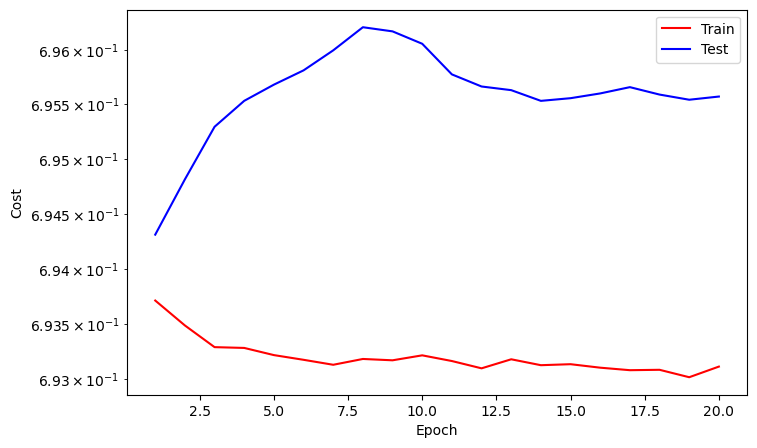

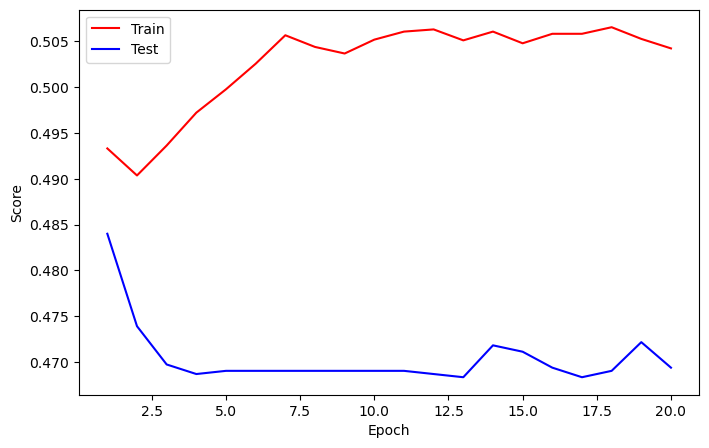

==> EarlyStop patience = 19 | Best test_score: 0.4840


─────────────────────────────────────────────────── 🚀 EPOCH 21 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 863.51it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6931 │ 0.6955 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4943 │ 0.5268 │ │ green │  0.4774  │
│ Subset Accuracy  │ 0.4238 │ 0.4280 │ │  red  │  0.4690  │
│ Micro F1         │ 0.4617 │ 0.4960 │ └───────┴──────────┘
│ Macro F1         │ 0.3161 │ 0.3988 │                     
│ Overall Accuracy │ 0.5057 │ 0.4732 │                     
└──────────────────┴────────┴────────┘


Epoch    21
Train_cost  = 0.6931 | Test_cost  = 0.6955 | Train_score = 0.5057 | Test_score = 0.4732 |
==> EarlyStop patience = 20 | Best test_score: 0.4840


...


Epoch    39
Train_cost  = 0.6930 | Test_cost  = 0.6947 | Train_score = 0.5047 | Test_score = 0.4875 |


─────────────────────────────────────────────────── 🚀 EPOCH 40 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1232.47it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6930 │ 0.6948 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4927 │ 0.5146 │ │ green │  0.5017  │
│ Subset Accuracy  │ 0.4358 │ 0.1733 │ │  red  │  0.4690  │
│ Micro F1         │ 0.4694 │ 0.6078 │ └───────┴──────────┘
│ Macro F1         │ 0.3199 │ 0.6036 │                     
│ Overall Accuracy │ 0.5073 │ 0.4854 │                     
└──────────────────┴────────┴────────┘


Epoch    40
Train_cost  = 0.6930 | Test_cost  = 0.6948 | Train_score = 0.5073 | Test_score = 0.4854 |


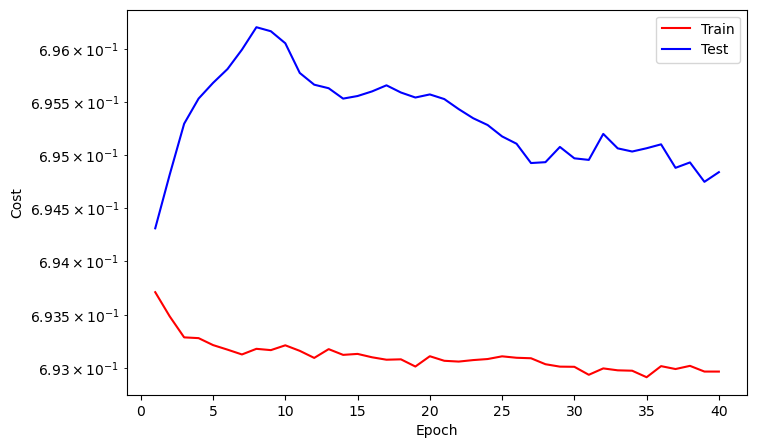

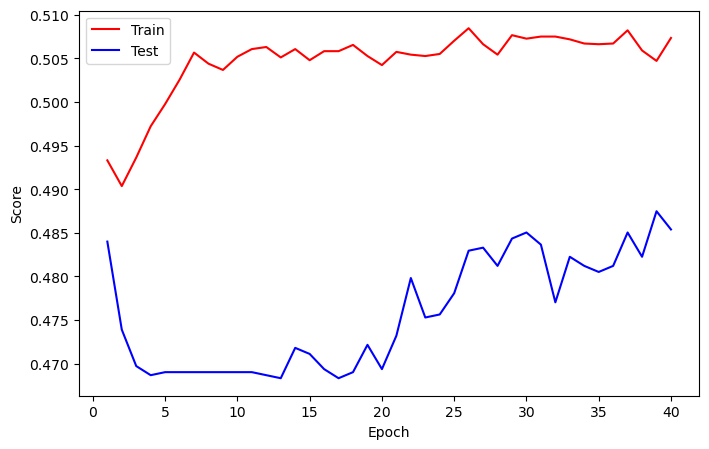

==> EarlyStop patience =  1 | Best test_score: 0.4875


─────────────────────────────────────────────────── 🚀 EPOCH 41 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1061.70it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6929 │ 0.6948 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4931 │ 0.5143 │ │ green │  0.5024  │
│ Subset Accuracy  │ 0.4173 │ 0.1531 │ │  red  │  0.4690  │
│ Micro F1         │ 0.4584 │ 0.6141 │ └───────┴──────────┘
│ Macro F1         │ 0.3150 │ 0.6113 │                     
│ Overall Accuracy │ 0.5069 │ 0.4857 │                     
└──────────────────┴────────┴────────┘


Epoch    41
Train_cost  = 0.6929 | Test_cost  = 0.6948 | Train_score = 0.5069 | Test_score = 0.4857 |
==> EarlyStop patience =  2 | Best test_score: 0.4875


...


Epoch    59
Train_cost  = 0.6929 | Test_cost  = 0.6940 | Train_score = 0.5100 | Test_score = 0.4937 |
==> EarlyStop patience =  1 | Best test_score: 0.4944


─────────────────────────────────────────────────── 🚀 EPOCH 60 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1170.67it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6928 │ 0.6938 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4912 │ 0.5028 │ │ green │  0.5240  │
│ Subset Accuracy  │ 0.4272 │ 0.0466 │ │  red  │  0.4704  │
│ Micro F1         │ 0.4776 │ 0.6534 │ └───────┴──────────┘
│ Macro F1         │ 0.4351 │ 0.6535 │                     
│ Overall Accuracy │ 0.5088 │ 0.4972 │                     
└──────────────────┴────────┴────────┘


Epoch    60
Train_cost  = 0.6928 | Test_cost  = 0.6938 | Train_score = 0.5088 | Test_score = 0.4972 |


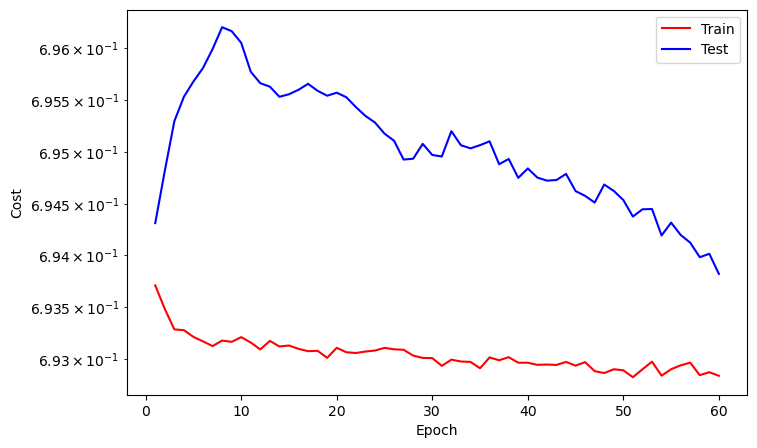

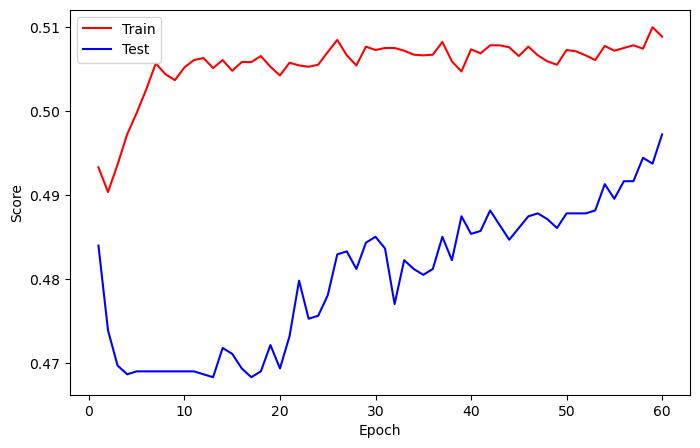

─────────────────────────────────────────────────── 🚀 EPOCH 61 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1203.71it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6929 │ 0.6940 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4888 │ 0.5049 │ │ green │  0.5212  │
│ Subset Accuracy  │ 0.4315 │ 0.0689 │ │  red  │  0.4690  │
│ Micro F1         │ 0.4813 │ 0.6460 │ └───────┴──────────┘
│ Macro F1         │ 0.4341 │ 0.6462 │                     
│ Overall Accuracy │ 0.5112 │ 0.4951 │                     
└──────────────────┴────────┴────────┘


Epoch    61
Train_cost  = 0.6929 | Test_cost  = 0.6940 | Train_score = 0.5112 | Test_score = 0.4951 |
==> EarlyStop patience =  1 | Best test_score: 0.4972


─────────────────────────────────────────────────── 🚀 EPOCH 62 ───────────────────────────────────────────────────

...


Epoch    79
Train_cost  = 0.6928 | Test_cost  = 0.6934 | Train_score = 0.5100 | Test_score = 0.5017 |


─────────────────────────────────────────────────── 🚀 EPOCH 80 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1124.78it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6928 │ 0.6934 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4892 │ 0.4962 │ │ green │  0.5233  │
│ Subset Accuracy  │ 0.4566 │ 0.1260 │ │  red  │  0.4843  │
│ Micro F1         │ 0.4970 │ 0.6399 │ └───────┴──────────┘
│ Macro F1         │ 0.4662 │ 0.6379 │                     
│ Overall Accuracy │ 0.5108 │ 0.5038 │                     
└──────────────────┴────────┴────────┘


Epoch    80
Train_cost  = 0.6928 | Test_cost  = 0.6934 | Train_score = 0.5108 | Test_score = 0.5038 |


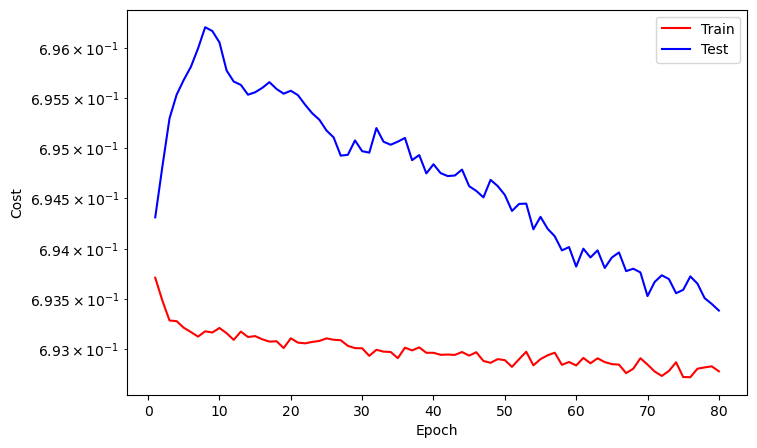

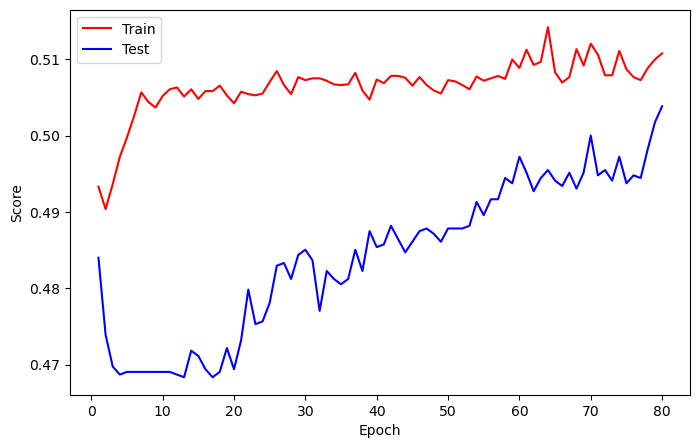

─────────────────────────────────────────────────── 🚀 EPOCH 81 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 868.97it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6928 │ 0.6934 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4906 │ 0.4976 │ │ green │  0.5212  │
│ Subset Accuracy  │ 0.4621 │ 0.1183 │ │  red  │  0.4836  │
│ Micro F1         │ 0.4960 │ 0.6405 │ └───────┴──────────┘
│ Macro F1         │ 0.4597 │ 0.6394 │                     
│ Overall Accuracy │ 0.5094 │ 0.5024 │                     
└──────────────────┴────────┴────────┘


Epoch    81
Train_cost  = 0.6928 | Test_cost  = 0.6934 | Train_score = 0.5094 | Test_score = 0.5024 |
==> EarlyStop patience =  1 | Best test_score: 0.5038


─────────────────────────────────────────────────── 🚀 EPOCH 82 ───────────────────────────────────────────────────

...


Epoch    99
Train_cost  = 0.6927 | Test_cost  = 0.6929 | Train_score = 0.5126 | Test_score = 0.5077 |
==> EarlyStop patience = 15 | Best test_score: 0.5108


────────────────────────────────────────────────── 🚀 EPOCH 100 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1152.72it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6927 │ 0.6929 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4893 │ 0.4910 │ │ green │  0.5303  │
│ Subset Accuracy  │ 0.4860 │ 0.2345 │ │  red  │  0.4878  │
│ Micro F1         │ 0.5095 │ 0.6148 │ └───────┴──────────┘
│ Macro F1         │ 0.4745 │ 0.6007 │                     
│ Overall Accuracy │ 0.5107 │ 0.5090 │                     
└──────────────────┴────────┴────────┘


Epoch   100
Train_cost  = 0.6927 | Test_cost  = 0.6929 | Train_score = 0.5107 | Test_score = 0.5090 |


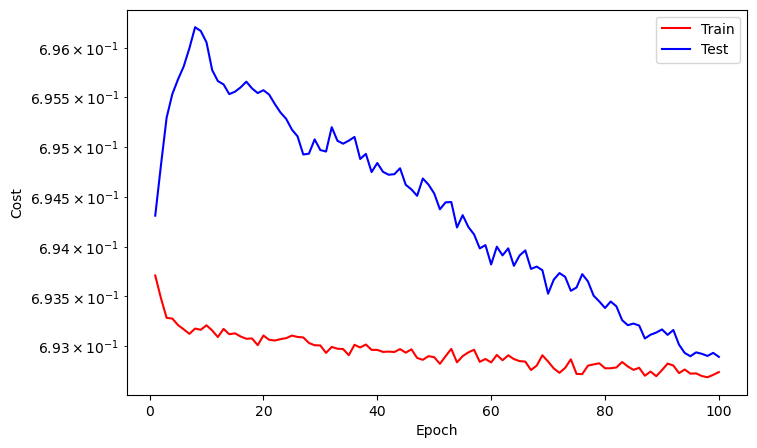

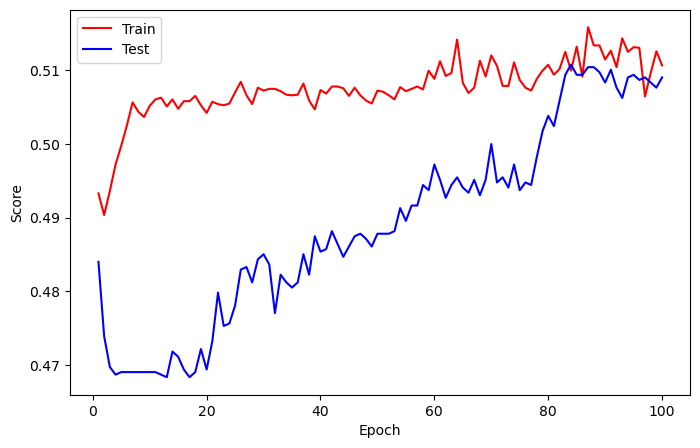

==> EarlyStop patience = 16 | Best test_score: 0.5108


────────────────────────────────────────────────── 🚀 EPOCH 101 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1200.28it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6928 │ 0.6930 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4916 │ 0.4965 │ │ green │  0.5240  │
│ Subset Accuracy  │ 0.4764 │ 0.2178 │ │  red  │  0.4830  │
│ Micro F1         │ 0.5007 │ 0.6138 │ └───────┴──────────┘
│ Macro F1         │ 0.4580 │ 0.6040 │                     
│ Overall Accuracy │ 0.5084 │ 0.5035 │                     
└──────────────────┴────────┴────────┘


Epoch   101
Train_cost  = 0.6928 | Test_cost  = 0.6930 | Train_score = 0.5084 | Test_score = 0.5035 |
==> EarlyStop patience = 17 | Best test_score: 0.5108


...


Epoch   119
Train_cost  = 0.6925 | Test_cost  = 0.6925 | Train_score = 0.5127 | Test_score = 0.5125 |
==> EarlyStop patience =  4 | Best test_score: 0.5146


────────────────────────────────────────────────── 🚀 EPOCH 120 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1219.09it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6928 │ 0.6925 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4903 │ 0.4885 │ │ green │  0.5324  │
│ Subset Accuracy  │ 0.4922 │ 0.3055 │ │  red  │  0.4906  │
│ Micro F1         │ 0.5087 │ 0.5949 │ └───────┴──────────┘
│ Macro F1         │ 0.4668 │ 0.5656 │                     
│ Overall Accuracy │ 0.5097 │ 0.5115 │                     
└──────────────────┴────────┴────────┘


Epoch   120
Train_cost  = 0.6928 | Test_cost  = 0.6925 | Train_score = 0.5097 | Test_score = 0.5115 |


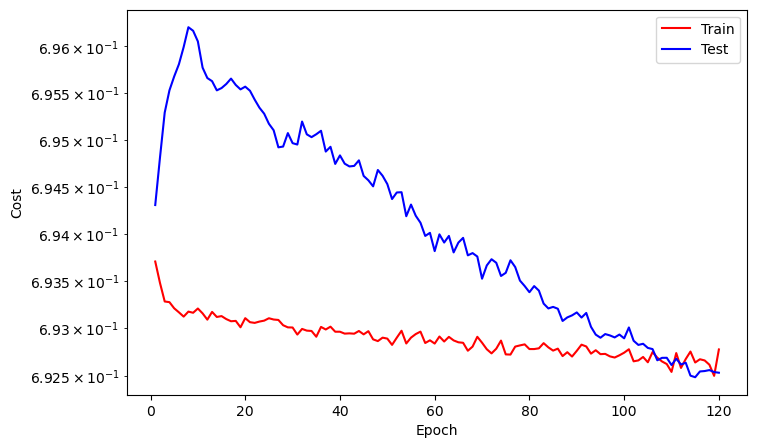

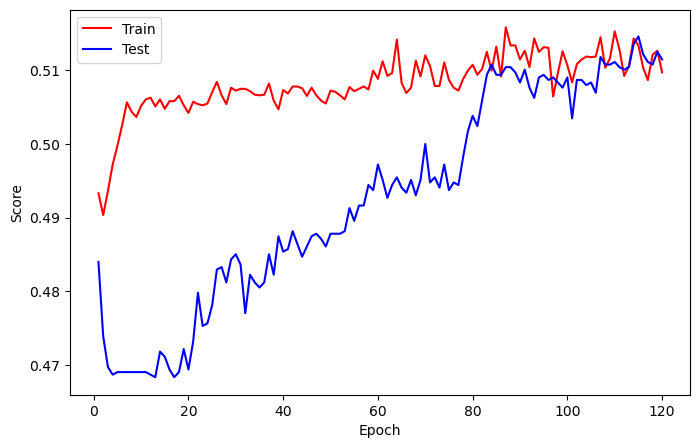

==> EarlyStop patience =  5 | Best test_score: 0.5146


────────────────────────────────────────────────── 🚀 EPOCH 121 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1067.06it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6926 │ 0.6924 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4882 │ 0.4809 │ │ green │  0.5344  │
│ Subset Accuracy  │ 0.4900 │ 0.3319 │ │  red  │  0.5038  │
│ Micro F1         │ 0.5078 │ 0.5950 │ └───────┴──────────┘
│ Macro F1         │ 0.4789 │ 0.5590 │                     
│ Overall Accuracy │ 0.5118 │ 0.5191 │                     
└──────────────────┴────────┴────────┘


Epoch   121
Train_cost  = 0.6926 | Test_cost  = 0.6924 | Train_score = 0.5118 | Test_score = 0.5191 |


...


Epoch   139
Train_cost  = 0.6925 | Test_cost  = 0.6922 | Train_score = 0.5105 | Test_score = 0.5212 |
==> EarlyStop patience =  4 | Best test_score: 0.5237


────────────────────────────────────────────────── 🚀 EPOCH 140 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1203.03it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6927 │ 0.6922 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4885 │ 0.4774 │ │ green │  0.5351  │
│ Subset Accuracy  │ 0.4935 │ 0.3974 │ │  red  │  0.5101  │
│ Micro F1         │ 0.5105 │ 0.5758 │ └───────┴──────────┘
│ Macro F1         │ 0.4837 │ 0.5138 │                     
│ Overall Accuracy │ 0.5115 │ 0.5226 │                     
└──────────────────┴────────┴────────┘


Epoch   140
Train_cost  = 0.6927 | Test_cost  = 0.6922 | Train_score = 0.5115 | Test_score = 0.5226 |


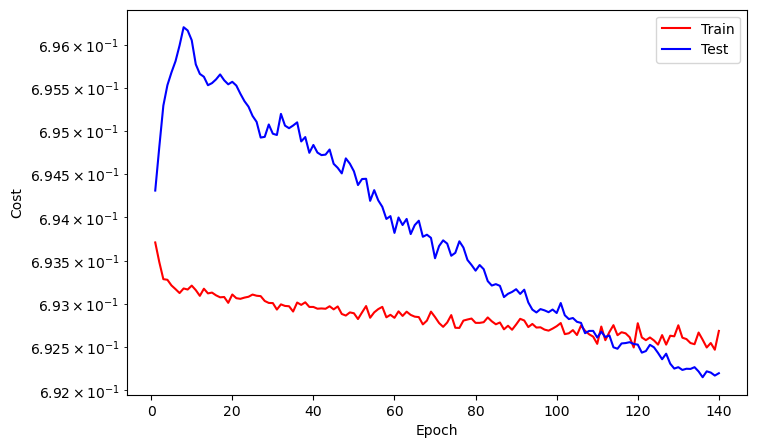

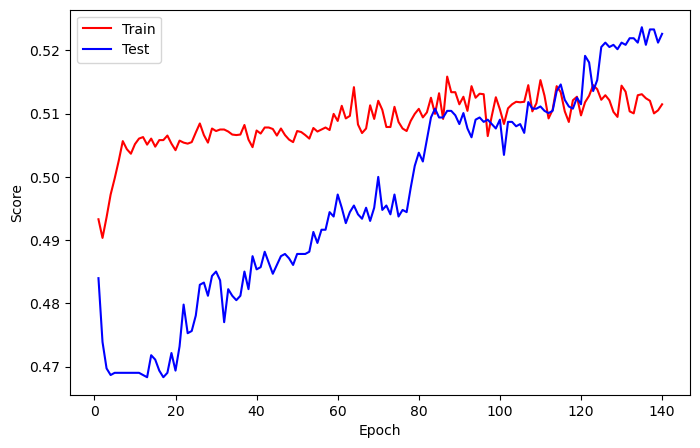

==> EarlyStop patience =  5 | Best test_score: 0.5237


────────────────────────────────────────────────── 🚀 EPOCH 141 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1186.80it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6926 │ 0.6921 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4872 │ 0.4809 │ │ green │  0.5324  │
│ Subset Accuracy  │ 0.4931 │ 0.4148 │ │  red  │  0.5059  │
│ Micro F1         │ 0.5103 │ 0.5646 │ └───────┴──────────┘
│ Macro F1         │ 0.5054 │ 0.4887 │                     
│ Overall Accuracy │ 0.5128 │ 0.5191 │                     
└──────────────────┴────────┴────────┘


Epoch   141
Train_cost  = 0.6926 | Test_cost  = 0.6921 | Train_score = 0.5128 | Test_score = 0.5191 |
==> EarlyStop patience =  6 | Best test_score: 0.5237


...


Epoch   159
Train_cost  = 0.6924 | Test_cost  = 0.6920 | Train_score = 0.5112 | Test_score = 0.5223 |
==> EarlyStop patience =  1 | Best test_score: 0.5240


────────────────────────────────────────────────── 🚀 EPOCH 160 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1092.00it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6925 │ 0.6920 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4890 │ 0.4774 │ │ green │  0.5324  │
│ Subset Accuracy  │ 0.4849 │ 0.4586 │ │  red  │  0.5129  │
│ Micro F1         │ 0.5050 │ 0.5513 │ └───────┴──────────┘
│ Macro F1         │ 0.4935 │ 0.4449 │                     
│ Overall Accuracy │ 0.5110 │ 0.5226 │                     
└──────────────────┴────────┴────────┘


Epoch   160
Train_cost  = 0.6925 | Test_cost  = 0.6920 | Train_score = 0.5110 | Test_score = 0.5226 |


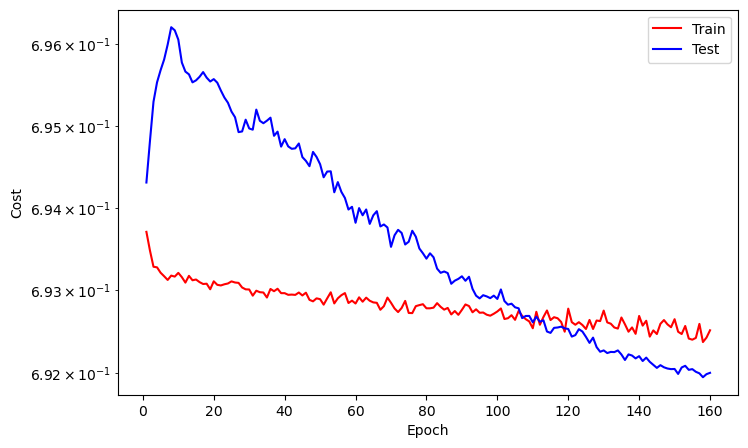

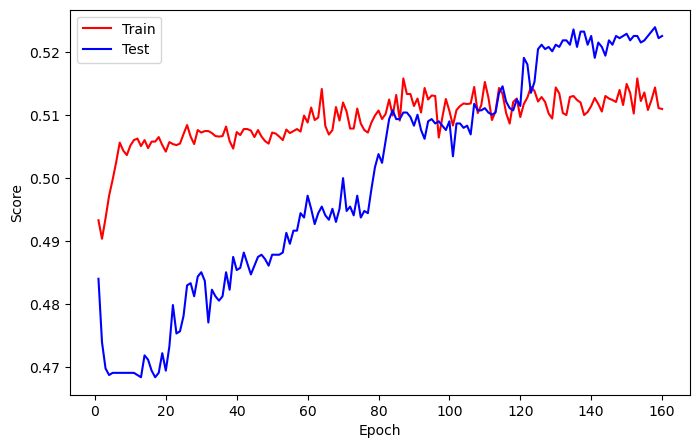

==> EarlyStop patience =  2 | Best test_score: 0.5240


────────────────────────────────────────────────── 🚀 EPOCH 161 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1052.33it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6925 │ 0.6920 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4848 │ 0.4770 │ │ green │  0.5331  │
│ Subset Accuracy  │ 0.4981 │ 0.4676 │ │  red  │  0.5129  │
│ Micro F1         │ 0.5133 │ 0.5480 │ └───────┴──────────┘
│ Macro F1         │ 0.5092 │ 0.4312 │                     
│ Overall Accuracy │ 0.5152 │ 0.5230 │                     
└──────────────────┴────────┴────────┘


Epoch   161
Train_cost  = 0.6925 | Test_cost  = 0.6920 | Train_score = 0.5152 | Test_score = 0.5230 |
==> EarlyStop patience =  3 | Best test_score: 0.5240


...


Epoch   179
Train_cost  = 0.6925 | Test_cost  = 0.6920 | Train_score = 0.5133 | Test_score = 0.5289 |


────────────────────────────────────────────────── 🚀 EPOCH 180 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 647.83it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6924 │ 0.6920 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4864 │ 0.4697 │ │ green │  0.5324  │
│ Subset Accuracy  │ 0.5054 │ 0.5052 │ │  red  │  0.5282  │
│ Micro F1         │ 0.5154 │ 0.5418 │ └───────┴──────────┘
│ Macro F1         │ 0.5134 │ 0.3961 │                     
│ Overall Accuracy │ 0.5136 │ 0.5303 │                     
└──────────────────┴────────┴────────┘


Epoch   180
Train_cost  = 0.6924 | Test_cost  = 0.6920 | Train_score = 0.5136 | Test_score = 0.5303 |


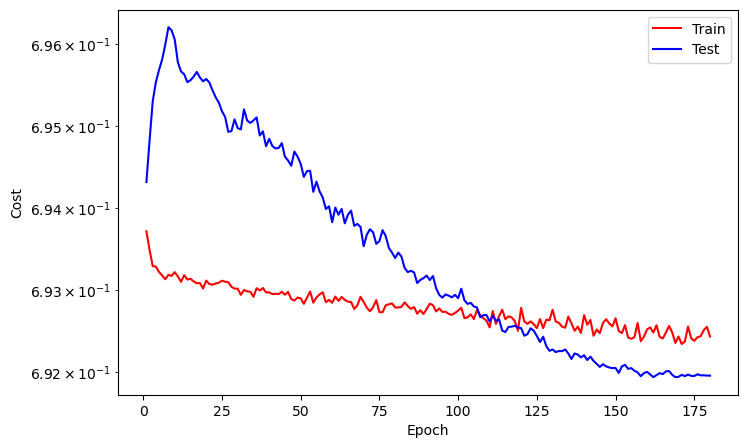

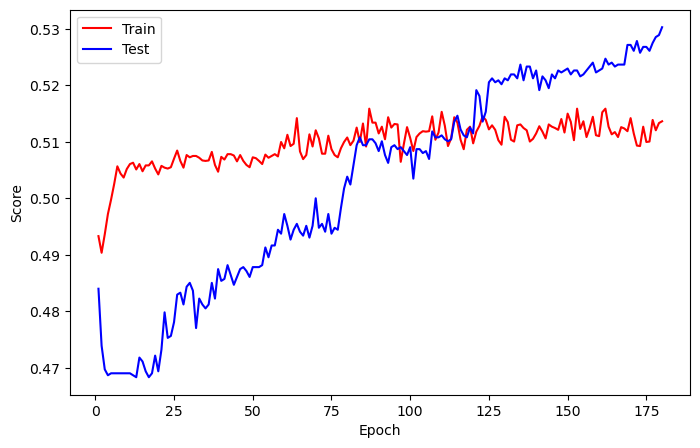

────────────────────────────────────────────────── 🚀 EPOCH 181 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1021.53it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6925 │ 0.6920 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4897 │ 0.4718 │ │ green │  0.5338  │
│ Subset Accuracy  │ 0.4896 │ 0.4920 │ │  red  │  0.5226  │
│ Micro F1         │ 0.5062 │ 0.5447 │ └───────┴──────────┘
│ Macro F1         │ 0.4953 │ 0.4108 │                     
│ Overall Accuracy │ 0.5103 │ 0.5282 │                     
└──────────────────┴────────┴────────┘


Epoch   181
Train_cost  = 0.6925 | Test_cost  = 0.6920 | Train_score = 0.5103 | Test_score = 0.5282 |
==> EarlyStop patience =  1 | Best test_score: 0.5303


────────────────────────────────────────────────── 🚀 EPOCH 182 ───────────────────────────────────────────────────

...


Epoch   199
Train_cost  = 0.6923 | Test_cost  = 0.6921 | Train_score = 0.5138 | Test_score = 0.5310 |
==> EarlyStop patience =  1 | Best test_score: 0.5327


────────────────────────────────────────────────── 🚀 EPOCH 200 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1209.88it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6924 │ 0.6921 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4878 │ 0.4687 │ │ green │  0.5324  │
│ Subset Accuracy  │ 0.4960 │ 0.5115 │ │  red  │  0.5303  │
│ Micro F1         │ 0.5101 │ 0.5404 │ └───────┴──────────┘
│ Macro F1         │ 0.4984 │ 0.3889 │                     
│ Overall Accuracy │ 0.5122 │ 0.5313 │                     
└──────────────────┴────────┴────────┘


Epoch   200
Train_cost  = 0.6924 | Test_cost  = 0.6921 | Train_score = 0.5122 | Test_score = 0.5313 |


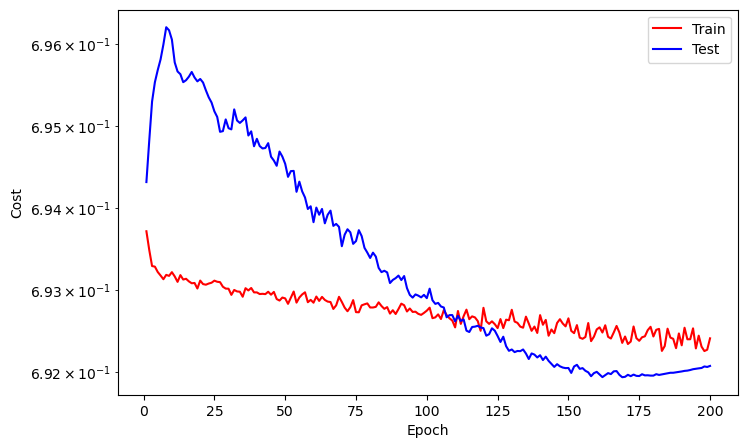

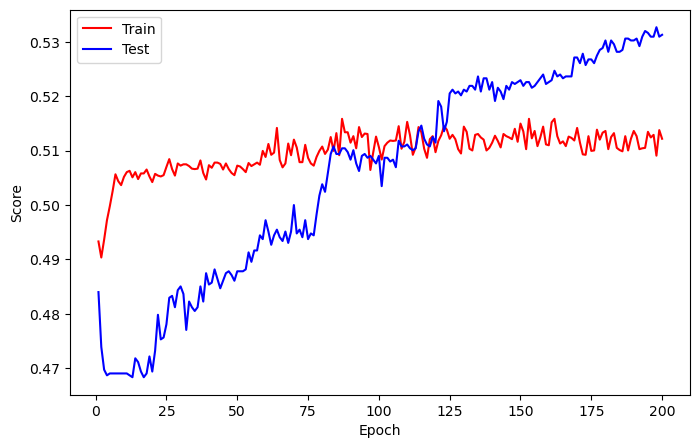

==> EarlyStop patience =  2 | Best test_score: 0.5327


────────────────────────────────────────────────── 🚀 EPOCH 201 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 984.62it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6925 │ 0.6921 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4872 │ 0.4673 │ │ green │  0.5324  │
│ Subset Accuracy  │ 0.4971 │ 0.5164 │ │  red  │  0.5331  │
│ Micro F1         │ 0.5106 │ 0.5402 │ └───────┴──────────┘
│ Macro F1         │ 0.4978 │ 0.3854 │                     
│ Overall Accuracy │ 0.5128 │ 0.5327 │                     
└──────────────────┴────────┴────────┘


Epoch   201
Train_cost  = 0.6925 | Test_cost  = 0.6921 | Train_score = 0.5128 | Test_score = 0.5327 |
==> EarlyStop patience =  3 | Best test_score: 0.5327


...


Epoch   219
Train_cost  = 0.6923 | Test_cost  = 0.6923 | Train_score = 0.5117 | Test_score = 0.5327 |
==> EarlyStop patience = 12 | Best test_score: 0.5344


────────────────────────────────────────────────── 🚀 EPOCH 220 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1222.12it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6923 │ 0.6924 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4876 │ 0.4669 │ │ green │  0.5317  │
│ Subset Accuracy  │ 0.4998 │ 0.5261 │ │  red  │  0.5344  │
│ Micro F1         │ 0.5120 │ 0.5363 │ └───────┴──────────┘
│ Macro F1         │ 0.5055 │ 0.3669 │                     
│ Overall Accuracy │ 0.5124 │ 0.5331 │                     
└──────────────────┴────────┴────────┘


Epoch   220
Train_cost  = 0.6923 | Test_cost  = 0.6924 | Train_score = 0.5124 | Test_score = 0.5331 |


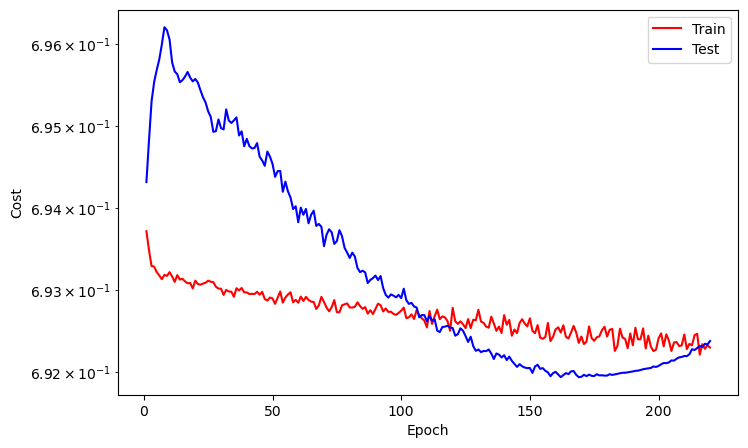

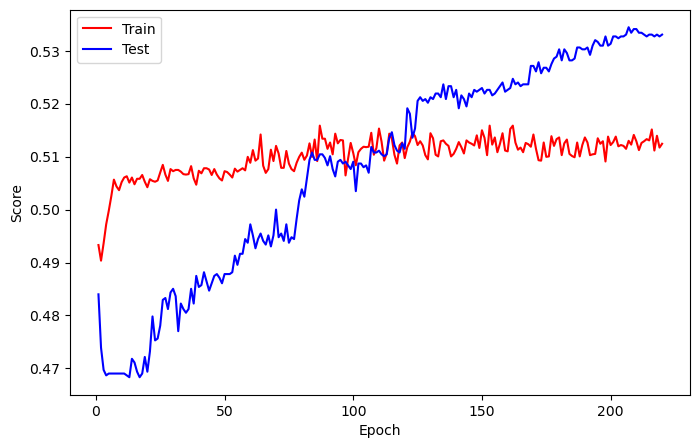

==> EarlyStop patience = 13 | Best test_score: 0.5344


────────────────────────────────────────────────── 🚀 EPOCH 221 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1211.95it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6922 │ 0.6924 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4874 │ 0.4680 │ │ green │  0.5310  │
│ Subset Accuracy  │ 0.5021 │ 0.5261 │ │  red  │  0.5331  │
│ Micro F1         │ 0.5130 │ 0.5348 │ └───────┴──────────┘
│ Macro F1         │ 0.5094 │ 0.3626 │                     
│ Overall Accuracy │ 0.5126 │ 0.5320 │                     
└──────────────────┴────────┴────────┘


Epoch   221
Train_cost  = 0.6922 | Test_cost  = 0.6924 | Train_score = 0.5126 | Test_score = 0.5320 |
==> EarlyStop patience = 14 | Best test_score: 0.5344


...


Epoch   236
Train_cost  = 0.6925 | Test_cost  = 0.6927 | Train_score = 0.5116 | Test_score = 0.5327 |
==> EarlyStop patience = 29 | Best test_score: 0.5344


────────────────────────────────────────────────── 🚀 EPOCH 237 ───────────────────────────────────────────────────

test: 100%|██████████| 45/45 [00:00<00:00, 1077.23it/s]


              📊 Summary                   🎯 Per-Label    
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓       Accuracy      
┃ Metric           ┃  Train ┃   Test ┃ ┏━━━━━━━┳━━━━━━━━━━┓
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩ ┃ Label ┃ Accuracy ┃
│ Loss             │ 0.6923 │ 0.6928 │ ┡━━━━━━━╇━━━━━━━━━━┩
│ Hamming Loss     │ 0.4866 │ 0.4673 │ │ green │  0.5317  │
│ Subset Accuracy  │ 0.5010 │ 0.5296 │ │  red  │  0.5338  │
│ Micro F1         │ 0.5125 │ 0.5342 │ └───────┴──────────┘
│ Macro F1         │ 0.5012 │ 0.3572 │                     
│ Overall Accuracy │ 0.5134 │ 0.5327 │                     
└──────────────────┴────────┴────────┘


Epoch   237
Train_cost  = 0.6923 | Test_cost  = 0.6928 | Train_score = 0.5134 | Test_score = 0.5327 |
==> EarlyStop patience = 30 | Best test_score: 0.5344
==> Execute Early Stopping at epoch: 237 | Best test_score: 0.5344
==> Best model is saved at timeseris/multi-label-clasification/rnn/microsoft_stock_data/


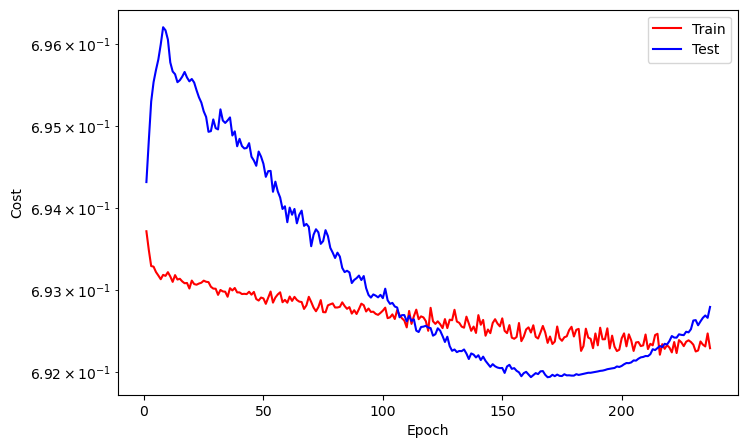

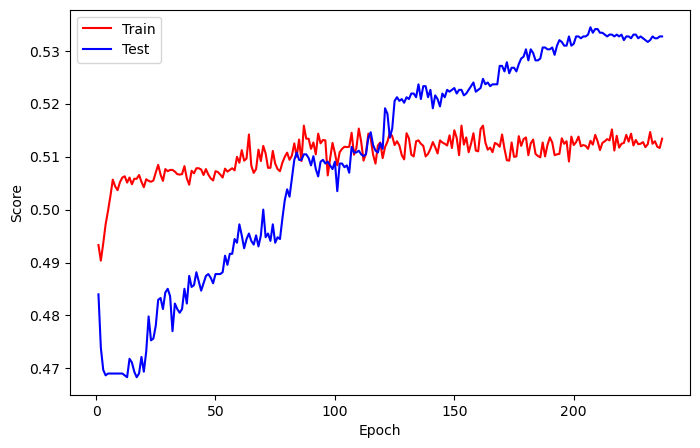

⏹️ Training dihentikan oleh early stopping.

In [19]:
from train_and_evaluate import train_and_evaluate_multi_label

train_and_evaluate_multi_label(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optim=optim,
    config=config,
    device=device,
    labels=labels,          
    callback=callback
)

# Evaluate

In [20]:
from evaluate import evaluate_multi_label

hsl = evaluate_multi_label(model, test_loader, target_cols,criterion, device, config.threshold)

       📊 Evaluasi Model         🎯 Per-Label Accuracy
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━┳━━━━━━━━━┓
┃ Metrik              ┃  Nilai ┃ ┃  Label  ┃ Akurasi ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━╇━━━━━━━━━┩
│ 🔹 Overall Accuracy │ 0.5344 │ │ y_green │ 0.5317  │
│ ✅ Subset  Accuracy │ 0.5233 │ │  y_red  │ 0.5372  │
│ 💥 Loss (avg)       │ 0.6922 │ └─────────┴─────────┘
│ 📉 Hamming Loss     │ 0.4656 │                      
│ ⚖️  Micro F1-score   │ 0.5396 │                      
│ 📈 Macro F1-score   │ 0.3790 │                      
└─────────────────────┴────────┘

In [21]:
hsl = hsl['df']
b = hsl[hsl['Benar (%)'] == 100]
b.head(300)

,Target,Prediksi,Benar (%)
2,"[1.0, 0.0]","[1.0, 0.0]",100.0
3,"[1.0, 0.0]","[1.0, 0.0]",100.0
5,"[1.0, 0.0]","[1.0, 0.0]",100.0
7,"[1.0, 0.0]","[1.0, 0.0]",100.0
10,"[1.0, 0.0]","[1.0, 0.0]",100.0
...,...,...,...
585,"[1.0, 0.0]","[1.0, 0.0]",100.0
586,"[1.0, 0.0]","[1.0, 0.0]",100.0
587,"[1.0, 0.0]","[1.0, 0.0]",100.0
590,"[1.0, 0.0]","[1.0, 0.0]",100.0


In [22]:
b.shape

(752, 3)

In [23]:
s = hsl[hsl['Benar (%)'] == 0]
s.head(300)

,Target,Prediksi,Benar (%)
0,"[0.0, 1.0]","[1.0, 0.0]",0.0
4,"[0.0, 1.0]","[1.0, 0.0]",0.0
8,"[0.0, 1.0]","[1.0, 0.0]",0.0
9,"[0.0, 1.0]","[1.0, 0.0]",0.0
13,"[0.0, 1.0]","[1.0, 0.0]",0.0
...,...,...,...
672,"[0.0, 1.0]","[1.0, 0.0]",0.0
673,"[0.0, 1.0]","[1.0, 0.0]",0.0
677,"[0.0, 1.0]","[1.0, 0.0]",0.0
678,"[0.0, 1.0]","[1.0, 0.0]",0.0


In [24]:
s.shape

(653, 3)